In [1]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torchvision.transforms.v2 as T
from IPython.display import clear_output
from PIL import Image
from matplotlib import cm
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.optim as optim
from torchvision.transforms.v2 import Compose, PILToTensor, ToDtype, Normalize

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rc('font', size=30)
device

device(type='cuda')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip /content/drive/MyDrive/ml-intensive-yandex-academy-spring-2026.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: dataset/train_images/55.jpg  
  inflating: dataset/train_images/550.jpg  
  inflating: dataset/train_images/5500.jpg  
  inflating: dataset/train_images/5501.jpg  
  inflating: dataset/train_images/5502.jpg  
  inflating: dataset/train_images/5503.jpg  
  inflating: dataset/train_images/5504.jpg  
  inflating: dataset/train_images/5505.jpg  
  inflating: dataset/train_images/5506.jpg  
  inflating: dataset/train_images/5507.jpg  
  inflating: dataset/train_images/5508.jpg  
  inflating: dataset/train_images/5509.jpg  
  inflating: dataset/train_images/551.jpg  
  inflating: dataset/train_images/5510.jpg  
  inflating: dataset/train_images/5511.jpg  
  inflating: dataset/train_images/5512.jpg  
  inflating: dataset/train_images/5513.jpg  
  inflating: dataset/train_images/5514.jpg  
  inflating: dataset/train_images/5515.jpg  
  inflating: dataset/train_images/5516.jpg  
  inflating: dataset/train_images/55

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
import os

class ImageClassificationDataset(Dataset):
    def __init__(self, df, transform=None):
        """
        Args:
            df: DataFrame с колонками 'full_path' (путь к фото) и 'label' (ответ)
            transform: Трансформации
        """
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Достаем путь к картинке и метку для конкретного индекса idx
        img_path = self.df.iloc[idx]['full_path']
        label = self.df.iloc[idx]['label']

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [5]:
import torchvision.transforms as transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

train_df_full = pd.read_csv('/content/dataset/train_solution.csv')
train_df_full.columns = ['id', 'label']

train_df_full['full_path'] = train_df_full['id'].apply(lambda x: f'/content/dataset/train_images/{x}.jpg')

train_df, val_df = train_test_split(train_df_full, test_size=0.2, random_state=42, stratify=train_df_full['label'])

# Для тестовых данных создадим отдельный DataFrame, так как меток нет
test_files = os.listdir('/content/dataset/test_images')
test_df = pd.DataFrame({
    'full_path': [os.path.join('/content/dataset/test_images', f) for f in test_files],
    'label': -1 
})

train_dataset_obj = ImageClassificationDataset(train_df, transform=transform)
val_dataset_obj = ImageClassificationDataset(val_df, transform=transform)
test_dataset_obj = ImageClassificationDataset(test_df, transform=transform)

print(f'Загружено тренировочных строк: {len(train_df)}')
print(f'Загружено валидационных строк: {len(val_df)}')
print(f'Загружено тестовых изображений: {len(test_df)}')
display(train_df.head())

Загружено тренировочных строк: 39999
Загружено валидационных строк: 10000
Загружено тестовых изображений: 10000


,id,label,full_path
31262,31263,0,/content/dataset/train_images/31263.jpg
36008,36009,0,/content/dataset/train_images/36009.jpg
38969,38970,0,/content/dataset/train_images/38970.jpg
33159,33160,0,/content/dataset/train_images/33160.jpg
5365,5366,0,/content/dataset/train_images/5366.jpg


In [ ]:
train_loader = DataLoader(train_dataset_obj, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset_obj, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset_obj, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

**Функции обучения и валидации модели**

In [ ]:
from tqdm import tqdm
from torch.optim import Optimizer, lr_scheduler
from torch import nn
from sklearn.metrics import f1_score
import numpy as np

def train(model: nn.Module, data_loader: DataLoader, optimizer: Optimizer, loss_fn, scheduler):
    model.train()
    total_loss = 0
    y_pred = []
    y_true = []

    for x, y in tqdm(data_loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)

        loss = loss_fn(pred, y.float().unsqueeze(1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        y_pred.extend((pred > 0.5).detach().cpu().numpy())
        y_true.extend(y.detach().cpu().numpy())

    scheduler.step()
    score = f1_score(y_true, y_pred)
    return total_loss / len(data_loader), score

In [9]:
def evaluate(model: nn.Module, test_loader: DataLoader, loss_fn):
    model.eval()
    total_loss = 0
    y_pred = []
    y_true = []

    with torch.no_grad():
        for x, y in tqdm(test_loader):
            x, y = x.to(device), y.to(device)
            pred = model(x)

            loss = loss_fn(pred, y.float().unsqueeze(1))
            total_loss += loss.item()

            y_pred.extend((pred > 0.5).cpu().numpy())
            y_true.extend(y.cpu().numpy())

    score = f1_score(y_true, y_pred)
    return total_loss / len(test_loader), score

In [15]:
def plot(train_loss_hist, train_score_hist, test_loss_hist, test_score_hist, title: str):
    clear_output()

    plt.figure(figsize = (16, 8))

    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    plt.title(title + ' loss')
    plt.plot(train_loss_hist, label = 'train_loss')
    plt.plot(test_loss_hist, label = 'test_loss')
    plt.legend()
    plt.show()

    plt.figure(figsize = (16, 8))

    plt.xlabel('Epochs')
    plt.ylabel('F1-score')

    plt.title(title + ' F1_score')
    plt.plot(train_score_hist, label = 'train_score')
    plt.plot(test_score_hist, label = 'test_score')
    plt.legend()
    plt.show()

In [ ]:
def fit(model: nn.Module, train_loader, test_loader, start_epoch, num_epohs, loss_fn, optimizer, scheduler, title: str):
    train_loss_hist, train_score_hist, test_loss_hist, test_score_hist = [], [], [], []

    for epoch in range (start_epoch, num_epohs):
        corr_train_loss, corr_train_score = train(model, train_loader, optimizer, loss_fn, scheduler)
        corr_test_loss, corr_test_score = evaluate(model, test_loader, loss_fn)

        train_loss_hist.append(corr_train_loss)
        train_score_hist.append(corr_train_score)
        test_loss_hist.append(corr_test_loss)
        test_score_hist.append(corr_test_score)

        checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': corr_train_loss,
        'val_loss': corr_test_loss,    
        'scheduler_state_dict': scheduler.state_dict(),
        }

        torch.save(checkpoint, f"{save_path}/checkpoint_epoch_{epoch}.pth")
        print(f"Эпоха {epoch} сохранена на Google Drive")

        plot(train_loss_hist, train_score_hist, test_loss_hist, test_score_hist, title)

In [12]:
save_path = '/content/drive/MyDrive/my_EfficientNet_model_checkpoints'
if not os.path.exists(save_path):
    os.makedirs(save_path)

In [ ]:
import torch
import torch.nn as nn
import math

class MBConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel, stride, expand_ratio, se_ratio=0.25):
        super().__init__()
        exp_channels = in_channels * expand_ratio

        # Расширение -> Глубинная свертка -> Сжатие
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, exp_channels, 1, bias=False),
            nn.BatchNorm2d(exp_channels),
            nn.SiLU(),

            nn.Conv2d(exp_channels, exp_channels, kernel, stride, kernel//2, groups=exp_channels, bias=False),
            nn.BatchNorm2d(exp_channels),
            nn.SiLU(),

            nn.Conv2d(exp_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        # Skip-connection
        self.use_residual = (stride == 1 and in_channels == out_channels)

    def forward(self, x):
        if self.use_residual:
            return x + self.block(x)
        return self.block(x)

class MyEfficientNet(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        # [expand_ratio, channels, repeats, stride, kernel_size]
        config = [
            [1, 16, 1, 1, 3],
            [6, 24, 2, 2, 3],
            [6, 40, 2, 2, 5],
            [6, 80, 3, 2, 3],
            [6, 112, 3, 1, 5],
            [6, 192, 4, 2, 5],
            [6, 320, 1, 1, 3],
        ]

        self.stem = nn.Sequential(nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.SiLU())

        layers = []
        in_ch = 32
        for exp, out_ch, repeat, strd, k in config:
            for i in range(repeat):
                layers.append(MBConv(in_ch, out_ch, k, strd if i == 0 else 1, exp))
                in_ch = out_ch

        self.features = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(320, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(self.stem(x)))

In [32]:
import torch
torch.cuda.empty_cache()
import gc
gc.collect()

21476

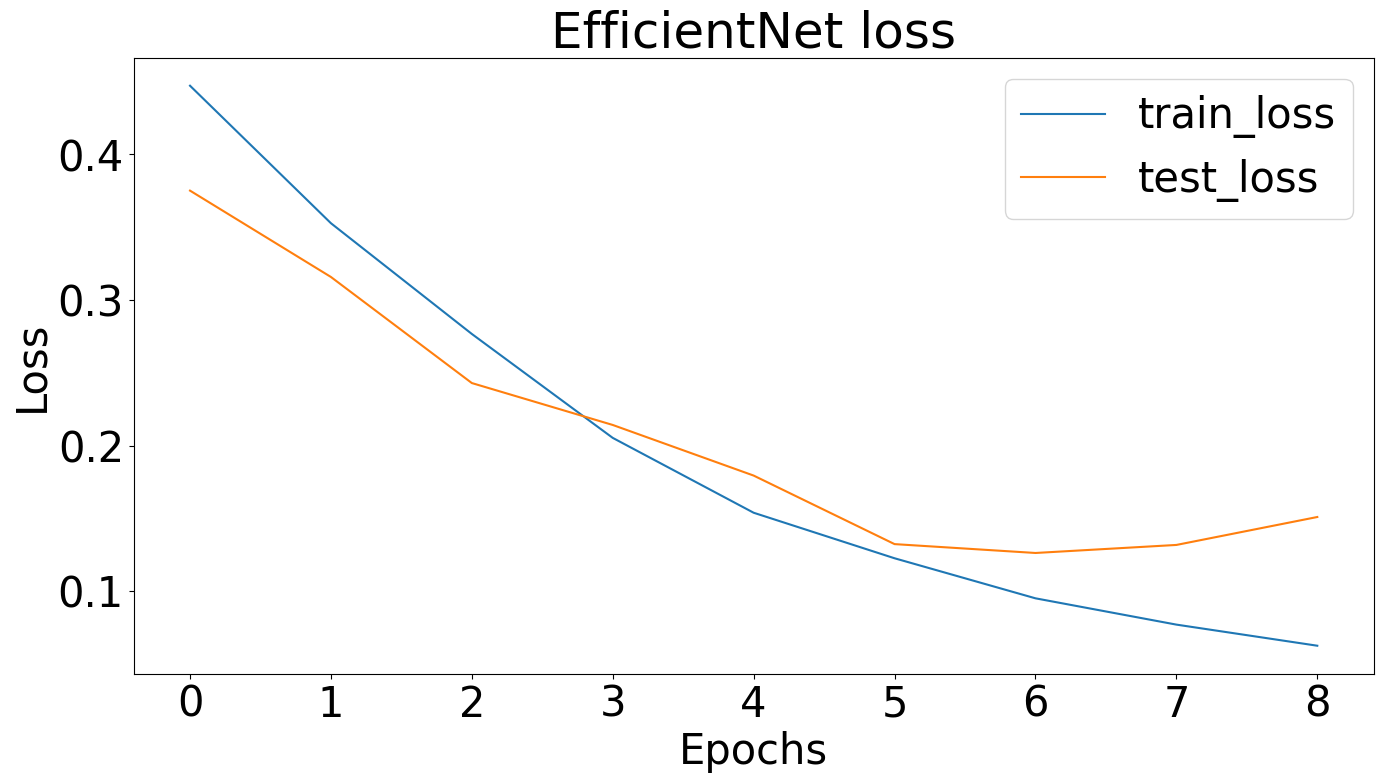

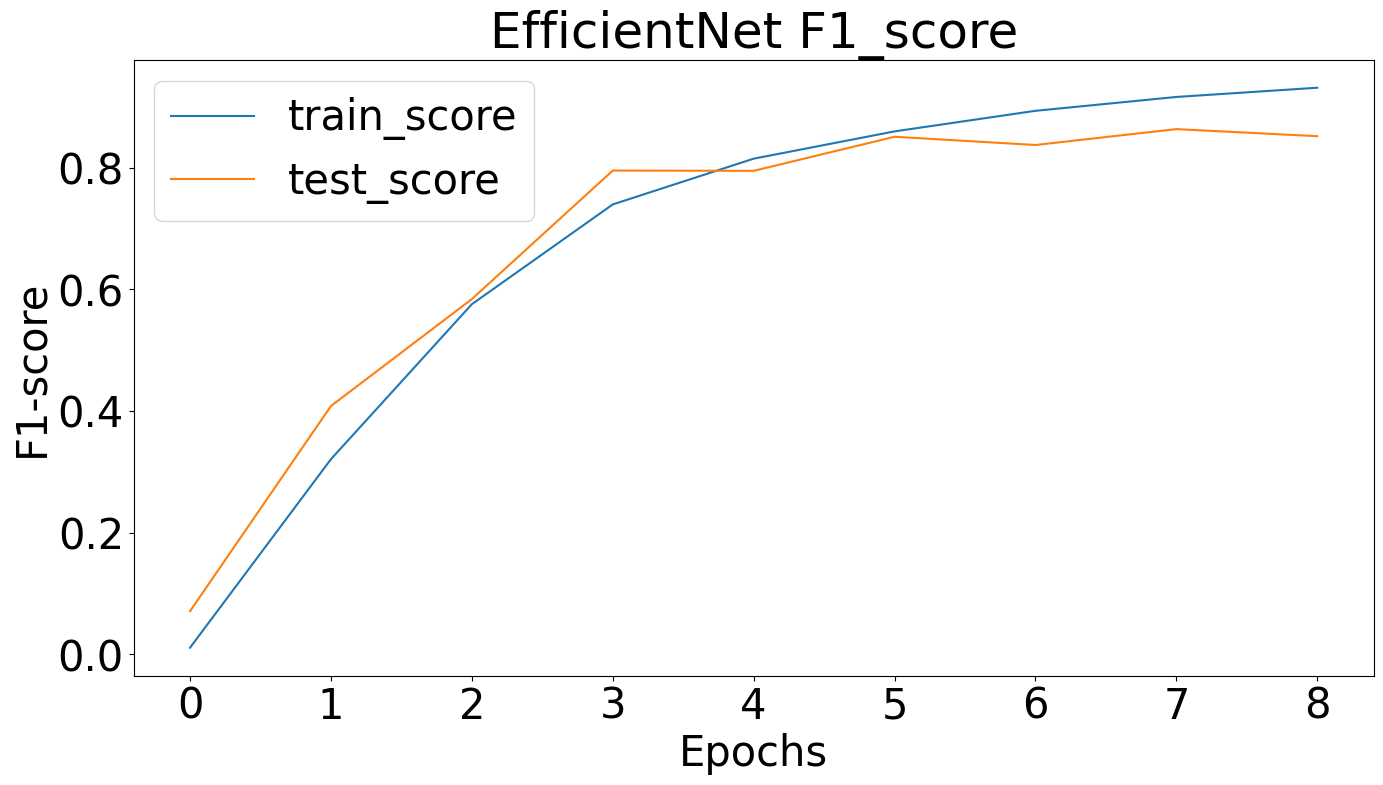

 16%|█▌        | 791/5000 [00:39<03:31, 19.87it/s]


KeyboardInterrupt: 

In [37]:
model = MyEfficientNet(num_classes=1)
model = model.to(device)
loss_function = nn.BCEWithLogitsLoss()
optimizer_for_Model = optim.Adam(model.parameters(), lr=1e-3)
scheduler_for_Model = lr_scheduler.CosineAnnealingLR(optimizer_for_Model, T_max=30, eta_min=1e-6)

fit(model, train_loader, val_loader, 0, 30, loss_function, optimizer_for_Model, scheduler_for_Model, "EfficientNet")

**Использовал EarlyStop т.к. очевидно стало, что модель начала переобучаться**

In [ ]:
# Загрузка модели
model = MyEfficientNet(num_classes=1)
checkpoint = torch.load("/content/drive/MyDrive/my_EfficientNet_model_checkpoints/checkpoint_epoch_8.pth")
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Путь к тестовым фоткам
test_images_path = "/content/dataset/test_images"

# Получаем список всех файлов
image_files = sorted([f for f in os.listdir(test_images_path) if f.endswith(('.jpg', '.png', '.jpeg'))])
print(f"Найдено {len(image_files)} изображений")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Делаем предсказания для всех фоток
predictions = []
for img_name in image_files:
    img_path = os.path.join(test_images_path, img_name)
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0)  # добавляем batch dimension

    with torch.no_grad():
        # Перемещаем тензор на то же устройство, что и модель
        img_tensor = img_tensor.to(device)
        model = model.to(device) # Убедимся, что модель на нужном устройстве

        output = model(img_tensor)
        # Для бинарной классификации (как в вашем случае с BCEWithLogitsLoss),
        # output - это логиты. Нужно применить сигмоиду и затем порог 0.5
        pred_proba = torch.sigmoid(output)
        pred_class = (pred_proba > 0.5).int().item()
        predictions.append(pred_class)

# Сохраняем в CSV
submission = pd.DataFrame({
    'id': [os.path.splitext(f)[0] for f in image_files],  # имя файла без расширения
    'target': predictions
})

# Важно: порядок строк должен соответствовать порядку id в sample_submission.csv
submission = submission.sort_values('id')

submission.to_csv('submission.csv', index=False)
print("✅ Файл submission.csv создан!")

Найдено 10000 изображений
✅ Файл submission.csv создан!
